# Homework 07. Сбор датасета с store.rvdural.ru и NLP-регрессия

**Источник:** интернет-магазин ООО «РВД Урал» — <https://store.rvdural.ru/>  
**Дата подготовки:** 19.07.2026  
**Версия парсера:** 2.0 — быстрые HTML-запросы выполняются из реального Chrome-контекста  
**Цель:** собрать все товарные позиции и максимум доступных сведений о каждой карточке, затем построить модель, связывающую текст товара с его ценой.

Ноутбук решает обе части задания:

1. Обходит весь каталог OpenCart, извлекает карточки товаров и URL всех изображений.
2. Формирует CSV и JSONL с плоскими и вложенными полями.
3. По желанию отдельным вторым этапом скачивает файлы изображений.
4. Делит данные на train/test в пропорции 75/25.
5. Строит TF–IDF по униграммам и биграммам, удаляет стоп-слова, редкие и слишком частые токены, отключает встроенную L2-нормировку TF–IDF (`norm=None`).
6. Настраивает коэффициент регуляризации линейной Ridge-регрессии, сравнивает её с константным baseline, считает MAE/RMSE/R²/MAPE и визуализирует 50 наиболее сильных коэффициентов.

> На сайте включена человекоориентированная проверка по цвету. Ноутбук **не обходит CAPTCHA автоматически**: Chrome остаётся открытым во время сбора, а при обновлении защитной cookie выполнение ставится на паузу и просит один раз нажать правильный цвет. Checkpoint позволяет продолжить с последней готовой карточки.


## 1. Установка и импорты

Первая ячейка устанавливает только общедоступные библиотеки. После установки ядро обычно перезапускать не требуется. Для Selenium нужен установленный Google Chrome; современный Selenium сам подбирает совместимый драйвер.


In [15]:
%pip install -q selenium requests beautifulsoup4 lxml pandas numpy scikit-learn matplotlib seaborn tqdm joblib


Note: you may need to restart the kernel to use updated packages.


In [16]:
import gzip
import hashlib
import html
import json
import random
import re
import time
from collections import deque
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import parse_qsl, urlencode, urljoin, urlparse, urlunparse
from urllib.robotparser import RobotFileParser

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from bs4 import BeautifulSoup
from IPython.display import display
from requests.adapters import HTTPAdapter
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from sklearn.dummy import DummyRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from tqdm.auto import tqdm
from urllib3.util.retry import Retry

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)


## 2. Параметры сбора

`MAX_PRODUCTS = None` означает **весь ассортимент**. Для короткой проверки кода можно временно поставить, например, `MAX_PRODUCTS = 20`, но итоговую выгрузку следует делать с `None`.

В версии 2.0 HTML карточек загружается через `fetch()` внутри Chrome: браузер передаёт корректный fingerprint и cookies, но не загружает CSS, JavaScript и картинки для каждой карточки. Это значительно быстрее обычной навигации Selenium и устойчивее прямых запросов `requests`.

`SAVE_IMAGES = False` относится только к скачиванию бинарных файлов. Даже в быстром режиме в датасет попадают **все полноразмерные URL изображений и их количество**. Поставьте `True`, только если нужны локальные копии: они скачаются отдельным вторым проходом после завершения основного датасета.


In [17]:
BASE_URL = "https://store.rvdural.ru/"
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data_rvdural"
IMAGE_DIR = DATA_DIR / "images"
HTML_DIR = DATA_DIR / "raw_html"
PROFILE_DIR = DATA_DIR / "chrome_profile"

CHECKPOINT_PATH = DATA_DIR / "products_checkpoint.jsonl"
CSV_PATH = DATA_DIR / "rvdural_products.csv"
JSONL_PATH = DATA_DIR / "rvdural_products.jsonl"
ERRORS_PATH = DATA_DIR / "scrape_errors.jsonl"
MODEL_PATH = DATA_DIR / "ridge_tfidf_price.joblib"

MAX_PRODUCTS = None          # None = собрать весь ассортимент
SAVE_IMAGES = False          # False = URL картинок в датасете; True = ещё и локальные файлы
SAVE_RAW_HTML = False        # True = сохранить gzip-копию каждой карточки
USE_BROWSER_FETCH = True     # быстрый HTML-fetch внутри Chrome вместо прямого requests
MIN_DELAY = 0.30             # ответственная задержка из условия задания
MAX_DELAY = 0.40
REQUEST_TIMEOUT = 40
MAX_CATEGORY_PAGES = 500
MAX_SESSION_REFRESHES = 20   # защита от бесконечного цикла CAPTCHA
RANDOM_STATE = 42

for directory in (DATA_DIR, IMAGE_DIR, HTML_DIR, PROFILE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Каталог результатов:", DATA_DIR.resolve())
print("Режим HTML:", "Chrome fetch" if USE_BROWSER_FETCH else "requests")
print("Локальное скачивание изображений:", SAVE_IMAGES)


Каталог результатов: C:\Users\Admin\OTUS.Professional\Homework_07\data_rvdural
Режим HTML: Chrome fetch
Локальное скачивание изображений: False


## 3. Вспомогательные функции и ответственная HTTP-сессия

Сессия делает паузу перед **каждым** запросом, повторяет временные ошибки и явно распознаёт антибот-страницу. В быстром режиме HTML получает настоящий Chrome через same-origin `fetch`, поэтому сервер видит браузерные headers/cookies, но карточка не тянет тяжёлые стили, скрипты и картинки.

Если защита всё же обновится, `fetch()` вызовет функцию восстановления браузерной сессии, попросит пройти проверку и автоматически повторит текущий URL. Прогресс не теряется.


In [18]:
SPACE_RE = re.compile(r"\s+")
BLOCK_MARKERS = (
    "sorry, your request has been denied",
    "если вы человек, нажмите на похожий цвет",
    "javascript is disabled",
    "идёт загрузка",
)

# Эти callback назначаются после запуска Chrome в разделе 4.
HTML_FETCHER = None
SESSION_REFRESH_CALLBACK = None


def clean_text(value):
    if value is None:
        return None
    return SPACE_RE.sub(" ", html.unescape(str(value))).strip()


def fix_mojibake(value):
    """Чинит типичное ошибочное чтение UTF-8 как Windows-1251, не меняя нормальный текст."""
    value = clean_text(value)
    if not value or not any(marker in value for marker in ("Р", "С", "вЂ", "В«", "В»")):
        return value
    try:
        repaired = value.encode("cp1251").decode("utf-8")
        if repaired.count("Р") + repaired.count("С") < value.count("Р") + value.count("С"):
            return repaired
    except (UnicodeEncodeError, UnicodeDecodeError):
        pass
    return value


def parse_number(value):
    if value is None:
        return None
    match = re.search(r"[-+]?\d[\d\s\u00a0]*(?:[.,]\d+)?", str(value))
    if not match:
        return None
    normalized = re.sub(r"[\s\u00a0]", "", match.group()).replace(",", ".")
    try:
        return float(normalized)
    except ValueError:
        return None


def canonicalize_url(url, keep_page=True):
    absolute = urljoin(BASE_URL, url)
    parsed = urlparse(absolute)
    if parsed.netloc.lower() != urlparse(BASE_URL).netloc.lower():
        return None
    allowed = {"page", "limit"} if keep_page else set()
    query = [(k, v) for k, v in parse_qsl(parsed.query) if k in allowed]
    path = re.sub(r"/{2,}", "/", parsed.path or "/")
    return urlunparse(("https", parsed.netloc.lower(), path, "", urlencode(query), ""))


def is_blocked_html(text):
    low = (text or "").lower()
    return any(marker in low for marker in BLOCK_MARKERS)


class PoliteSession(requests.Session):
    def __init__(self, min_delay=0.30, max_delay=0.40):
        super().__init__()
        self.min_delay = min_delay
        self.max_delay = max_delay
        self._last_request = 0.0

    def wait_turn(self):
        elapsed = time.monotonic() - self._last_request
        wait_for = random.uniform(self.min_delay, self.max_delay) - elapsed
        if wait_for > 0:
            time.sleep(wait_for)
        self._last_request = time.monotonic()

    def request(self, method, url, **kwargs):
        self.wait_turn()
        return super().request(method, url, **kwargs)


def configure_retries(session):
    retry = Retry(
        total=4,
        connect=4,
        read=4,
        status=4,
        backoff_factor=1.2,
        status_forcelist=(408, 425, 429, 500, 502, 503, 504),
        allowed_methods=frozenset(("GET", "HEAD")),
        respect_retry_after_header=True,
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=4, pool_maxsize=4)
    session.mount("https://", adapter)
    session.mount("http://", adapter)


def response_from_browser(payload, requested_url):
    if not payload or payload.get("error"):
        raise RuntimeError(f"Ошибка browser fetch для {requested_url}: {payload.get('error') if payload else 'нет ответа'}")
    response = requests.Response()
    response.status_code = int(payload.get("status", 0))
    response.url = payload.get("url") or requested_url
    response.headers.update(payload.get("headers") or {})
    response._content = (payload.get("text") or "").encode("utf-8")
    response.encoding = "utf-8"
    return response


def fetch(session, url, binary=False, allow_block=False):
    """Получает URL; HTML — через Chrome, бинарные файлы — через requests."""
    attempts = 3
    for attempt in range(1, attempts + 1):
        if not binary and callable(HTML_FETCHER):
            session.wait_turn()
            response = response_from_browser(HTML_FETCHER(url), url)
        else:
            response = session.get(url, timeout=REQUEST_TIMEOUT)
            if not binary:
                response.encoding = response.encoding or "utf-8"

        blocked = not binary and is_blocked_html(response.text)
        if blocked and not allow_block:
            if callable(SESSION_REFRESH_CALLBACK) and attempt < attempts:
                print(f"\nЗащитная cookie обновляется; текущий URL сохранён: {url}")
                SESSION_REFRESH_CALLBACK(url)
                continue
            raise RuntimeError(
                "Сайт снова показал защитную страницу после нескольких восстановлений. "
                "Checkpoint сохранён; перезапустите раздел 4 и затем раздел 7."
            )

        response.raise_for_status()
        return response

    raise RuntimeError(f"Не удалось получить {url}")


## 4. Получение разрешённой браузерной сессии

Откроется Chrome с отдельным профилем внутри `data_rvdural/chrome_profile`. Если показана цветовая проверка, нажмите правильный цвет **самостоятельно**, дождитесь магазина и вернитесь в ноутбук.

Chrome после этого **не закрывается**: лёгкие HTML-запросы выполняются прямо из его контекста через JavaScript `fetch()`. При повторном появлении защиты ноутбук сам откроет проблемный URL, попросит подтверждение и продолжит с той же позиции. Браузер закроется после полного сбора в разделе 7.


In [19]:
chrome_options = Options()
chrome_options.add_argument(f"--user-data-dir={PROFILE_DIR.resolve()}")
chrome_options.add_argument("--start-maximized")
chrome_options.add_argument("--lang=ru-RU")
chrome_options.add_experimental_option("excludeSwitches", ["enable-logging"])
# Файлы картинок не нужны для CAPTCHA (цвета заданы CSS), зато навигация легче.
chrome_options.add_experimental_option(
    "prefs", {"profile.managed_default_content_settings.images": 2}
)
chrome_options.page_load_strategy = "eager"

driver = webdriver.Chrome(options=chrome_options)
driver.set_script_timeout(REQUEST_TIMEOUT)

session = PoliteSession(MIN_DELAY, MAX_DELAY)
configure_retries(session)
_session_refresh_count = 0


def browser_body_text():
    bodies = driver.find_elements("tag name", "body")
    return bodies[0].text if bodies else ""


def copy_browser_state_to_requests():
    session.cookies.clear()
    user_agent = driver.execute_script("return navigator.userAgent")
    session.headers.update({
        "User-Agent": user_agent,
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
        "Accept-Language": "ru-RU,ru;q=0.9,en;q=0.7",
        "Referer": BASE_URL,
    })
    for cookie in driver.get_cookies():
        session.cookies.set(
            cookie["name"], cookie["value"],
            domain=cookie.get("domain"), path=cookie.get("path", "/")
        )
    return user_agent


def refresh_browser_session(problem_url=BASE_URL):
    global _session_refresh_count
    _session_refresh_count += 1
    if _session_refresh_count > MAX_SESSION_REFRESHES:
        raise RuntimeError("Превышен MAX_SESSION_REFRESHES: остановка защищает от бесконечного цикла CAPTCHA.")

    driver.get(problem_url)
    time.sleep(3)
    if is_blocked_html(browser_body_text()):
        input(
            "В открытом Chrome пройдите цветовую проверку, дождитесь карточки "
            "товара и нажмите Enter здесь..."
        )
        time.sleep(2)

    if is_blocked_html(browser_body_text()):
        raise RuntimeError("Проверка не завершена: Chrome всё ещё показывает защитную страницу.")

    copy_browser_state_to_requests()
    # Паркуем вкладку на том же origin, чтобы последующие browser fetch были same-origin.
    if not driver.current_url.startswith(BASE_URL):
        driver.get(BASE_URL)
        time.sleep(2)
    print("Браузерная сессия обновлена; продолжаем с checkpoint.")


def browser_fetch_payload(url):
    script = r"""
        const url = arguments[0];
        const done = arguments[arguments.length - 1];
        fetch(url, {credentials: 'include', cache: 'no-store', redirect: 'follow'})
          .then(async response => done({
              status: response.status,
              url: response.url,
              headers: Object.fromEntries(response.headers.entries()),
              text: await response.text()
          }))
          .catch(error => done({error: String(error)}));
    """
    return driver.execute_async_script(script, url)


refresh_browser_session(BASE_URL)
HTML_FETCHER = browser_fetch_payload if USE_BROWSER_FETCH else None
SESSION_REFRESH_CALLBACK = refresh_browser_session

check = fetch(session, BASE_URL)
check_title = BeautifulSoup(check.text, "lxml").title
print("HTTP:", check.status_code, "| title:", check_title.get_text(strip=True) if check_title else "без title")
print("Режим:", "HTML через Chrome fetch" if callable(HTML_FETCHER) else "прямой requests")


В открытом Chrome пройдите цветовую проверку, дождитесь карточки товара и нажмите Enter здесь... 


Браузерная сессия обновлена; продолжаем с checkpoint.
HTTP: 200 | title: Интернет-магазин ООО РВД Урал
Режим: HTML через Chrome fetch


### Проверка robots.txt

Парсер не игнорирует правила сайта. Если `robots.txt` доступен и запрещает каталог для нашего User-Agent, выполнение прекращается. Если вместо файла сервер возвращает защитную HTML-страницу, это явно выводится, и остаётся консервативная задержка из настроек выше.


In [20]:
robots_url = urljoin(BASE_URL, "robots.txt")
robots_response = fetch(session, robots_url, allow_block=True)
robots_text = robots_response.text

if "text/plain" in robots_response.headers.get("Content-Type", "") and "User-agent" in robots_text:
    robots = RobotFileParser()
    robots.set_url(robots_url)
    robots.parse(robots_text.splitlines())
    if not robots.can_fetch(browser_user_agent, BASE_URL):
        raise PermissionError("robots.txt запрещает обход каталога для текущего User-Agent.")
    crawl_delay = robots.crawl_delay(browser_user_agent) or robots.crawl_delay("*")
    if crawl_delay:
        session.min_delay = max(session.min_delay, float(crawl_delay))
        session.max_delay = max(session.max_delay, float(crawl_delay))
    print(robots_text[:3000])
else:
    print("robots.txt не удалось интерпретировать как текст правил; используем паузу", MIN_DELAY, "–", MAX_DELAY, "с.")


User-agent: *
Disallow: /*route=account/
Disallow: /*route=affiliate/
Disallow: /*route=checkout/
Disallow: /*route=product/search
Disallow: /index.php?route=product/product*&manufacturer_id=
Disallow: /admin
Disallow: /catalog
Disallow: /system
Disallow: /*?sort=
Disallow: /*&sort=
Disallow: /*?order=
Disallow: /*&order=
Disallow: /*?limit=
Disallow: /*&limit=
Disallow: /*?filter_name=
Disallow: /*&filter_name=
Disallow: /*?filter_sub_category=
Disallow: /*&filter_sub_category=
Disallow: /*?filter_description=
Disallow: /*&filter_description=
Disallow: /*?tracking=
Disallow: /*&tracking=
Disallow: *?gtm_debug=
Disallow: *?etext=
Disallow: /*?filter=
Disallow: /*&filter=
Disallow: /*compare-products
Disallow: *search=*
Disallow: *page=*
Disallow: /*cart
Disallow: /*checkout
Disallow: /*login
Disallow: /*logout
Disallow: /*vouchers
Disallow: /*wishlist
Disallow: /*my-account
Disallow: /*order-history
Disallow: /*newsletter
Disallow: /*return-add
Disallow: /*forgot-password
Disallow: /*d

## 5. Поиск всех URL товаров

Используются два независимых способа:

- стандартные sitemap-адреса OpenCart, если они включены;
- обход всех категорий из меню и всех страниц пагинации с `limit=100`.

Товарные URL извлекаются только из карточек `.product-thumb`. Повторяющиеся товары из родительских/дочерних категорий дедуплицируются по canonical URL.


In [21]:
def parse_sitemap_xml(xml_text):
    soup = BeautifulSoup(xml_text, "xml")
    child_sitemaps = [clean_text(tag.get_text()) for tag in soup.find_all("sitemap") for tag in tag.find_all("loc", recursive=False)]
    urls = [clean_text(tag.get_text()) for tag in soup.find_all("url") for tag in tag.find_all("loc", recursive=False)]
    return child_sitemaps, urls


def discover_sitemap_urls(session):
    initial = [
        urljoin(BASE_URL, "sitemap.xml"),
        urljoin(BASE_URL, "sitemap_index.xml"),
        urljoin(BASE_URL, "index.php?route=extension/feed/google_sitemap"),
        urljoin(BASE_URL, "index.php?route=feed/google_sitemap"),
    ]
    queue = deque(initial)
    seen_maps, found = set(), set()
    while queue:
        sitemap_url = queue.popleft()
        if sitemap_url in seen_maps:
            continue
        seen_maps.add(sitemap_url)
        try:
            response = fetch(session, sitemap_url, allow_block=True)
            if "<urlset" not in response.text and "<sitemapindex" not in response.text:
                continue
            child_maps, urls = parse_sitemap_xml(response.text)
            queue.extend(child_maps)
            for url in urls:
                normalized = canonicalize_url(url, keep_page=False)
                if normalized:
                    found.add(normalized)
        except Exception as exc:
            print("Sitemap пропущен:", sitemap_url, type(exc).__name__)
    return found


def add_limit(url, limit=100):
    parsed = urlparse(url)
    query = dict(parse_qsl(parsed.query))
    query["limit"] = str(limit)
    return urlunparse(parsed._replace(query=urlencode(query)))


def discover_catalog_urls(session, home_html):
    home = BeautifulSoup(home_html, "lxml")
    category_selector = ",".join((
        "a.menu__level-1-a", "a.menu__level-2-a", "a.menu__level-3-a",
        ".category-wall a", ".category-list a", ".subcategory a",
    ))
    categories = {
        canonicalize_url(a.get("href"), keep_page=False)
        for a in home.select(category_selector) if a.get("href")
    }
    categories.discard(None)

    product_urls = {
        canonicalize_url(a.get("href"), keep_page=False)
        for a in home.select("a.product-thumb__name") if a.get("href")
    }
    product_urls.discard(None)

    page_queue = deque(add_limit(url) for url in sorted(categories))
    seen_pages = set()

    progress = tqdm(desc="Страницы каталога", unit="стр.")
    while page_queue:
        page_url = page_queue.popleft()
        normalized_page = canonicalize_url(page_url, keep_page=True)
        if not normalized_page or normalized_page in seen_pages:
            continue
        if len(seen_pages) >= MAX_CATEGORY_PAGES:
            raise RuntimeError("Достигнут защитный MAX_CATEGORY_PAGES — проверьте отсутствие цикла пагинации.")
        seen_pages.add(normalized_page)

        response = fetch(session, normalized_page)
        soup = BeautifulSoup(response.text, "lxml")
        for a in soup.select("a.product-thumb__name"):
            url = canonicalize_url(a.get("href"), keep_page=False)
            if url:
                product_urls.add(url)

        for a in soup.select(".pagination a"):
            url = canonicalize_url(a.get("href"), keep_page=True)
            if url and url not in seen_pages:
                page_queue.append(add_limit(url))

        for a in soup.select(".category-wall a, .category-list a, .subcategory a"):
            url = canonicalize_url(a.get("href"), keep_page=False)
            if url and url not in categories:
                categories.add(url)
                page_queue.append(add_limit(url))

        progress.update(1)
        progress.set_postfix(products=len(product_urls), categories=len(categories))
    progress.close()
    return product_urls, categories, seen_pages


sitemap_urls = discover_sitemap_urls(session)
catalog_product_urls, category_urls, catalog_pages = discover_catalog_urls(session, check.text)

# Точные URL из карточек каталога приоритетны: sitemap также содержит служебные страницы.
# Sitemap остаётся fallback на случай изменения селекторов темы.
candidate_source = catalog_product_urls if catalog_product_urls else sitemap_urls
candidate_urls = sorted(candidate_source)
if MAX_PRODUCTS is not None:
    candidate_urls = candidate_urls[:MAX_PRODUCTS]

print("URL из sitemap:", len(sitemap_urls))
print("Категорий:", len(category_urls))
print("Страниц каталога:", len(catalog_pages))
print("Товарных ссылок из карточек:", len(catalog_product_urls))
print("Кандидатов к сбору:", len(candidate_urls))
print("Источник кандидатов:", "карточки каталога" if catalog_product_urls else "sitemap fallback")
assert candidate_urls, "Не найдено ни одного URL: проверьте сессию и селекторы."


Sitemap пропущен: https://store.rvdural.ru/sitemap_index.xml HTTPError
Sitemap пропущен: https://store.rvdural.ru/index.php?route=feed/google_sitemap HTTPError


Страницы каталога: 0стр. [00:00, ?стр./s]

URL из sitemap: 4203
Категорий: 136
Страниц каталога: 200
Товарных ссылок из карточек: 4011
Кандидатов к сбору: 4011
Источник кандидатов: карточки каталога


## 6. Извлечение максимально полной карточки

Для каждого товара сохраняются:

- URL, canonical URL, внутренний `product_id`, название, артикул/SKU/model/MPN;
- производитель/бренд, категории и хлебные крошки;
- цена, старая/акционная цена, валюта, скидка;
- исходный текст наличия и числовой остаток (если число показано);
- единица остатка только при явном наличии на странице, минимальный заказ и шаг;
- полное описание (текст + HTML), характеристики, опции/варианты;
- все полноразмерные URL изображений и локальные файлы;
- meta-теги, основная microdata `Product`, полный текст карточки, время сбора;
- при `SAVE_RAW_HTML=True` — исходный HTML в gzip.

Вложенные структуры хранятся как JSON-строки в CSV и как настоящие объекты в JSONL.


In [22]:
def text_of(node):
    return fix_mojibake(node.get_text(" ", strip=True)) if node else None


def extract_labeled_items(root):
    result = {}
    if not root:
        return result
    for item in root.select(".product-data__item"):
        label_node = item.select_one(".product-data__item-div")
        if not label_node:
            continue
        label = text_of(label_node).rstrip(":")
        whole = text_of(item) or ""
        value = clean_text(whole[len(text_of(label_node) or ""):].lstrip(" :"))
        if label and value:
            result[label] = value
    return result


def extract_attributes(soup):
    attributes = {}
    attributes.update(extract_labeled_items(soup.select_one(".product-page__short-attribute")))
    specification = soup.select_one("#tab-specification")
    if specification:
        current_group = None
        for row in specification.select("tr"):
            cells = row.find_all(["th", "td"], recursive=False)
            values = [text_of(cell) for cell in cells if text_of(cell)]
            if len(values) == 1:
                current_group = values[0]
            elif len(values) >= 2:
                key = f"{current_group} / {values[0]}" if current_group else values[0]
                attributes[key] = values[1]
    return attributes


def extract_options(soup):
    options = []
    main = soup.select_one(".product-page")
    if not main:
        return options
    for block in main.select(".option, [id^='input-option']"):
        label = text_of(block.select_one("label, .control-label"))
        control = block.select_one("select, input, textarea")
        if not control:
            continue
        option = {
            "label": label,
            "name": control.get("name"),
            "type": control.name if control.name != "input" else control.get("type"),
            "required": "required" in (block.get("class") or []),
        }
        if control.name == "select":
            option["values"] = [
                {"value": tag.get("value"), "text": text_of(tag)}
                for tag in control.select("option")
            ]
        else:
            option["value"] = control.get("value")
        if option not in options:
            options.append(option)
    return options


def extract_primary_microdata(soup):
    root = soup.select_one("[itemscope][itemtype$='/Product']")
    if not root:
        return {}
    result = {}
    for node in root.select("[itemprop]"):
        prop = node.get("itemprop")
        if prop in result and prop not in ("additionalProperty", "image"):
            continue
        value = node.get("content") or node.get("href") or node.get("src") or text_of(node)
        if not value:
            continue
        if prop in result:
            if not isinstance(result[prop], list):
                result[prop] = [result[prop]]
            if value not in result[prop]:
                result[prop].append(value)
        else:
            result[prop] = value
    return result


def infer_stock_unit(attributes, description):
    for key, value in attributes.items():
        if re.search(r"единиц|измерен|упаков|фасов", key, flags=re.I):
            return value
    match = re.search(r"(?:остаток|наличие)\s*:?\s*\d+(?:[.,]\d+)?\s*(шт\.?|м\.?|метр(?:а|ов)?|компл\.?|упак\.?|кг)", description or "", re.I)
    return match.group(1) if match else None


def parse_product_page(html_text, requested_url):
    soup = BeautifulSoup(html_text, "lxml")
    main = soup.select_one(".product-page")
    name_node = soup.select_one("h1.heading")
    price_node = soup.select_one(".product-page__price")
    if not main or not name_node or not (price_node or soup.select_one("[itemtype$='/Product']")):
        return None

    product_data = extract_labeled_items(soup.select_one(".product-block .product-data"))
    attributes = extract_attributes(soup)
    description_node = soup.select_one("#tab-description")
    description = text_of(description_node)
    description_html = str(description_node.decode_contents()) if description_node else None

    stock_node = soup.select_one(".product-block .qty-indicator__text")
    stock_text = text_of(stock_node)
    stock_quantity = parse_number(stock_text)

    price = parse_number(price_node.get("data-price") if price_node else None)
    special_price = parse_number(price_node.get("data-special") if price_node else None)
    discount = clean_text(price_node.get("data-discount")) if price_node else None

    images = []
    for image in main.select("img.product-page__image-main-img"):
        url = image.get("data-full") or image.get("data-thumb") or image.get("src")
        url = urljoin(requested_url, url) if url else None
        if url and url not in images:
            images.append(url)

    breadcrumbs = [text_of(node) for node in soup.select(".breadcrumb li") if text_of(node)]
    category_tags = [text_of(node) for node in soup.select(".product-tag__item") if text_of(node)]
    categories = list(dict.fromkeys(breadcrumbs[1:-1] + category_tags))

    canonical_node = soup.select_one("link[rel='canonical']")
    canonical_url = canonicalize_url(canonical_node.get("href"), keep_page=False) if canonical_node else canonicalize_url(requested_url, False)

    meta = {}
    for node in soup.select("head meta[name], head meta[property]"):
        key = node.get("name") or node.get("property")
        value = fix_mojibake(node.get("content"))
        if key and value:
            meta[key] = value

    product_id_node = main.select_one("input[name='product_id']")
    product_id = product_id_node.get("value") if product_id_node else None
    if not product_id:
        match = re.search(r"(?:wishlist|compare)\.add\((\d+)\)", str(main))
        product_id = match.group(1) if match else None

    quantity_node = main.select_one("input[name='quantity']")
    minimum_order = parse_number(quantity_node.get("min") or quantity_node.get("value")) if quantity_node else None
    order_step = parse_number(quantity_node.get("step")) if quantity_node else None

    microdata = extract_primary_microdata(soup)
    sku = product_data.get("Артикул") or microdata.get("sku") or microdata.get("model")
    manufacturer = product_data.get("Производитель") or microdata.get("manufacturer") or microdata.get("brand")
    currency = microdata.get("priceCurrency") or "RUB"

    model_text = " ".join(filter(None, [text_of(name_node), description, " ".join(f"{k}: {v}" for k, v in attributes.items())]))
    record = {
        "url": canonicalize_url(requested_url, keep_page=False),
        "canonical_url": canonical_url,
        "product_id": product_id,
        "name": text_of(name_node),
        "sku": fix_mojibake(sku),
        "model": fix_mojibake(microdata.get("model")),
        "mpn": fix_mojibake(microdata.get("mpn")),
        "manufacturer": fix_mojibake(manufacturer),
        "brand": fix_mojibake(microdata.get("brand")),
        "price": price if price is not None else parse_number(microdata.get("price")),
        "special_price": special_price if special_price not in (None, 0) else None,
        "discount": discount or None,
        "currency": currency,
        "availability_schema": microdata.get("availability"),
        "stock_text": stock_text,
        "stock_quantity": stock_quantity,
        "stock_unit": infer_stock_unit(attributes, description),
        "minimum_order": minimum_order,
        "order_step": order_step,
        "description": description,
        "description_html": description_html,
        "attributes": attributes,
        "options": extract_options(soup),
        "categories": categories,
        "breadcrumbs": breadcrumbs,
        "image_urls": images,
        "image_count": len(images),
        "meta": meta,
        "microdata": microdata,
        "product_page_text": text_of(main),
        "text_for_model": fix_mojibake(model_text),
        "scraped_at_utc": datetime.now(timezone.utc).isoformat(),
        "source_site": BASE_URL,
    }
    return record


# Проверка функции на одной реально найденной карточке
sample_url = next(iter(sorted(catalog_product_urls)))
sample_response = fetch(session, sample_url)
sample_record = parse_product_page(sample_response.text, sample_url)
assert sample_record and sample_record["name"] and sample_record["canonical_url"]
display(pd.Series({k: v for k, v in sample_record.items() if k not in ("description_html", "product_page_text", "microdata")}))


url                                                                                                     https://store.rvdural.ru/adaptery/adapter-dkm-sh-sh-30h2-36h2-s-41-1m-30-36-a/
canonical_url                                                                                           https://store.rvdural.ru/adaptery/adapter-dkm-sh-sh-30h2-36h2-s-41-1m-30-36-a/
product_id                                                                                                                                                                        4641
name                                                                                                                                     Адаптер DKM Ш/Ш 30х2 - 36х2 S=41 — 1M-30-36 A
sku                                                                                                                                                                         1M-30-36 A
model                                                                                

## 7. Быстрый полный сбор с checkpoint и опциональные изображения

Основной проход делает ровно один лёгкий HTML-запрос на товар. Изображения **не загружаются в память**, но все их полноразмерные URL и количество сохраняются.

Если `SAVE_IMAGES=True`, только после готовности текстового датасета начинается отдельный проход бинарных файлов. Поэтому медленные картинки больше не задерживают получение таблицы и не мешают NLP. Изображения дедуплицируются по SHA-1 содержимого; ошибка картинки записывается в `image_errors` и не уничтожает карточку.

При обрыве повторно выполните разделы 4, 5 и 7: `products_checkpoint.jsonl` пропустит уже готовые canonical URL.


In [23]:
def safe_file_stem(value):
    value = clean_text(value) or "product"
    value = re.sub(r"[^0-9A-Za-zА-Яа-яЁё._-]+", "_", value).strip("._")
    return value[:100] or "product"


def append_jsonl(path, obj):
    with Path(path).open("a", encoding="utf-8") as file:
        file.write(json.dumps(obj, ensure_ascii=False) + "\n")


def download_product_images(session, record):
    local_paths, errors = [], []
    stem = safe_file_stem(record.get("sku") or record.get("product_id") or record.get("name"))
    for index, image_url in enumerate(record.get("image_urls", []), start=1):
        try:
            response = fetch(session, image_url, binary=True)
            content_type = response.headers.get("Content-Type", "").split(";")[0].lower()
            if not content_type.startswith("image/"):
                raise ValueError(f"ожидалось изображение, получено {content_type}")
            digest = hashlib.sha1(response.content).hexdigest()[:12]
            extension = {
                "image/jpeg": ".jpg", "image/png": ".png", "image/webp": ".webp",
                "image/gif": ".gif", "image/avif": ".avif",
            }.get(content_type, Path(urlparse(image_url).path).suffix.lower() or ".img")
            path = IMAGE_DIR / f"{stem}__{index:02d}_{digest}{extension}"
            if not path.exists():
                path.write_bytes(response.content)
            local_paths.append(str(path.relative_to(PROJECT_DIR)))
        except Exception as exc:
            errors.append({"url": image_url, "error": f"{type(exc).__name__}: {exc}"})
    return local_paths, errors


def load_checkpoint(path):
    records = {}
    path = Path(path)
    if not path.exists():
        return records
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                record = json.loads(line)
                if record.get("canonical_url"):
                    records[record["canonical_url"]] = record
            except json.JSONDecodeError:
                print(f"Пропущена повреждённая строка checkpoint: {line_number}")
    return records


records_by_url = load_checkpoint(CHECKPOINT_PATH)
already_done = set(records_by_url)
print("Уже собрано из checkpoint:", len(already_done))
print("Осталось проверить:", sum(canonicalize_url(url, False) not in already_done for url in candidate_urls))

for url in tqdm(candidate_urls, desc="Карточки товаров", unit="товар"):
    normalized = canonicalize_url(url, keep_page=False)
    if normalized in already_done:
        continue
    try:
        response = fetch(session, normalized)
        record = parse_product_page(response.text, normalized)
        if record is None:
            continue

        # Бинарные изображения намеренно вынесены во второй проход.
        record["image_local_paths"] = []
        record["image_errors"] = []

        if SAVE_RAW_HTML:
            raw_path = HTML_DIR / f"{safe_file_stem(record.get('sku') or record.get('product_id'))}.html.gz"
            with gzip.open(raw_path, "wt", encoding="utf-8") as file:
                file.write(response.text)
            record["raw_html_path"] = str(raw_path.relative_to(PROJECT_DIR))
        else:
            record["raw_html_path"] = None

        append_jsonl(CHECKPOINT_PATH, record)
        records_by_url[record["canonical_url"]] = record
        already_done.add(record["canonical_url"])
    except Exception as exc:
        error = {
            "url": normalized,
            "error": f"{type(exc).__name__}: {exc}",
            "time_utc": datetime.now(timezone.utc).isoformat(),
        }
        append_jsonl(ERRORS_PATH, error)
        if isinstance(exc, RuntimeError):
            raise

records = list(records_by_url.values())
print("Итого уникальных товаров:", len(records))
assert records, "Не собрано ни одного товара."

# Необязательный второй проход. Он также работает для записей из старого checkpoint.
if SAVE_IMAGES:
    for record in tqdm(records, desc="Локальные изображения", unit="товар"):
        expected = len(record.get("image_urls") or [])
        current = len(record.get("image_local_paths") or [])
        if current >= expected:
            continue
        local_paths, image_errors = download_product_images(session, record)
        record["image_local_paths"] = local_paths
        record["image_errors"] = image_errors
        append_jsonl(CHECKPOINT_PATH, record)  # последняя версия canonical URL победит при resume

try:
    driver.quit()
except Exception:
    pass
HTML_FETCHER = None
SESSION_REFRESH_CALLBACK = None
print("Chrome закрыт. Основной сбор завершён; можно выполнять экспорт и NLP.")


Уже собрано из checkpoint: 0
Осталось проверить: 4011


Карточки товаров:   0%|          | 0/4011 [00:00<?, ?товар/s]


Защитная cookie обновляется; текущий URL сохранён: https://store.rvdural.ru/adaptery/adaptery-bsp/adapter-bsp-sh-g-3-4-1-2-s-32-2b-12-08/


В открытом Chrome пройдите цветовую проверку, дождитесь карточки товара и нажмите Enter здесь... 


Браузерная сессия обновлена; продолжаем с checkpoint.

Защитная cookie обновляется; текущий URL сохранён: https://store.rvdural.ru/adaptery/adaptery-jis/adapter-jis-sh-sh-22x1-5-22x1-5-s-27-1k-22/


...

Браузерная сессия обновлена; продолжаем с checkpoint.

Защитная cookie обновляется; текущий URL сохранён: https://store.rvdural.ru/prochee/usit/prokladka-usit-r-d-2-usf-r2/


В открытом Chrome пройдите цветовую проверку, дождитесь карточки товара и нажмите Enter здесь... 


Браузерная сессия обновлена; продолжаем с checkpoint.

Защитная cookie обновляется; текущий URL сохранён: https://store.rvdural.ru/rvd/rvd-1sn-2sn/1-1-4-2sn-rukav-vys-davleniya-dy32-py-125semperit/


В открытом Chrome пройдите цветовую проверку, дождитесь карточки товара и нажмите Enter здесь... 


Браузерная сессия обновлена; продолжаем с checkpoint.
Итого уникальных товаров: 4007
Chrome закрыт. Основной сбор завершён; можно выполнять экспорт и NLP.


## 8. Экспорт полного датасета

JSONL — основной формат без потери вложенности. CSV удобен для просмотра в pandas/Excel; списки и словари в нём сериализованы в JSON.

При `SAVE_IMAGES=False` поля `image_urls` и `image_count` полностью заполнены, а `image_local_paths` пуст. Это быстрый рекомендуемый вариант. При `SAVE_IMAGES=True` локальные копии дополнительно находятся в `data_rvdural/images`.


In [24]:
with JSONL_PATH.open("w", encoding="utf-8") as file:
    for record in records:
        file.write(json.dumps(record, ensure_ascii=False) + "\n")

flat_records = []
for record in records:
    flat = {}
    for key, value in record.items():
        flat[key] = json.dumps(value, ensure_ascii=False) if isinstance(value, (dict, list)) else value
    flat_records.append(flat)

products_df = pd.DataFrame(flat_records)
products_df = products_df.drop_duplicates(subset=["canonical_url"], keep="last")
products_df.to_csv(CSV_PATH, index=False, encoding="utf-8-sig")

print("CSV:", CSV_PATH.resolve(), CSV_PATH.stat().st_size, "байт")
print("JSONL:", JSONL_PATH.resolve(), JSONL_PATH.stat().st_size, "байт")
print("Изображений на диске:", sum(1 for path in IMAGE_DIR.rglob("*") if path.is_file()))
print("Размер таблицы:", products_df.shape)
display(products_df.head(3))


CSV: C:\Users\Admin\OTUS.Professional\Homework_07\data_rvdural\rvdural_products.csv 37086290 байт
JSONL: C:\Users\Admin\OTUS.Professional\Homework_07\data_rvdural\rvdural_products.jsonl 39017174 байт
Изображений на диске: 0
Размер таблицы: (4007, 36)


,url,canonical_url,product_id,name,sku,model,mpn,manufacturer,brand,price,special_price,discount,currency,availability_schema,stock_text,stock_quantity,stock_unit,minimum_order,order_step,description,description_html,attributes,options,categories,breadcrumbs,image_urls,image_count,meta,microdata,product_page_text,text_for_model,scraped_at_utc,source_site,image_local_paths,image_errors,raw_html_path
0,https://store.rvdural.ru/adaptery/adapter-dkm-sh-sh-30h2-36h2-s-41-1m-30-36-a/,https://store.rvdural.ru/adaptery/adapter-dkm-sh-sh-30h2-36h2-s-41-1m-30-36-a/,4641,Адаптер DKM Ш/Ш 30х2 - 36х2 S=41 — 1M-30-36 A,1M-30-36 A,1M-30-36 A,1M-30-36 A,АМО Сталь,АМО Сталь,173.33,None,None,RUB,http://schema.org/InStock,166,166.0,None,1.0,None,"Адаптер (0) DKM-DKM 30х2-36х2 (Ш/Ш) S=41 , артикул – 1M-30-36 A применяется для быстрого резьбового соединения рукавов высокого давления. Адаптер (0) DKM-DK...","<p><strong>Адаптер (0) DKM-DKM 30х2-36х2 (Ш/Ш) S=41</strong>, артикул – <b>1M-30-36 A</b> применяется для быстрого резьбового соединения рукавов высокого да...","{""Тип адаптера"": ""Адаптер прямой"", ""Стандарты"": ""DKM-DKM"", ""Конструкция адаптера"": ""(Ш/Ш)""}",[],[],"[""Адаптеры"", ""Адаптер (0) DKM-DKM 30х2-36х2 (Ш/Ш) S=41 — арт. 1M-30-36 A""]","[""https://store.rvdural.ru/image/cache/catalog/1m-1200x800.jpg""]",1,"{""viewport"": ""width=device-width, initial-scale=1, maximum-scale=3"", ""description"": ""Адаптер (0) DKM-DKM 30х2-36х2 (Ш/Ш) S=41 артикул 1M-30-36 A собственног...","{""name"": ""Адаптер DKM Ш/Ш 30х2 - 36х2 S=41 — 1M-30-36 A"", ""url"": ""https://store.rvdural.ru/adaptery/adapter-dkm-sh-sh-30h2-36h2-s-41-1m-30-36-a/"", ""image"": ...",*Фото могут не соответствовать характеристикам. Уточняйте всю необходимую информацию у менеджера перед покупкой . Артикул: 1M-30-36 A Производитель: АМО Ста...,"Адаптер DKM Ш/Ш 30х2 - 36х2 S=41 — 1M-30-36 A Адаптер (0) DKM-DKM 30х2-36х2 (Ш/Ш) S=41 , артикул – 1M-30-36 A применяется для быстрого резьбового соединения...",2026-07-19T16:37:56.581997+00:00,https://store.rvdural.ru/,[],[],None
1,https://store.rvdural.ru/adaptery/adapter-jic-sh-sh-5-8-5-8-s-17-1j-07/,https://store.rvdural.ru/adaptery/adapter-jic-sh-sh-5-8-5-8-s-17-1j-07/,4590,"Адаптер JIC Ш/Ш 5/8""-5/8"" S=17 — 1J-07",1J-07,1J-07,1J-07,Китай,Китай,66.07,None,None,RUB,http://schema.org/InStock,1,1.0,None,1.0,None,"Адаптер (0) JIC-JIC 5/8""-5/8"" (Ш/Ш) S=17 , артикул – 1J-07 применяется для быстрого резьбового соединения рукавов высокого давления. Адаптер (0) JIC-JIC 5/8...","<p><strong>Адаптер (0) JIC-JIC 5/8""-5/8"" (Ш/Ш) S=17</strong>, артикул – <b>1J-07</b> применяется для быстрого резьбового соединения рукавов высокого давлени...","{""Тип адаптера"": ""Адаптер прямой"", ""Стандарты"": ""JIC-JIC"", ""Конструкция адаптера"": ""(Ш/Ш)""}",[],[],"[""Адаптеры"", ""Адаптер (0) JIC-JIC 5/8\""-5/8\"" (Ш/Ш) S=17 — арт. 1J-07""]","[""https://store.rvdural.ru/image/cache/catalog/cat/2884-1-1200x800.jpg"", ""https://store.rvdural.ru/image/cache/catalog/cat/2884-2-1200x800.jpg"", ""https://st...",3,"{""viewport"": ""width=device-width, initial-scale=1, maximum-scale=3"", ""description"": ""Адаптер (0) JIC-JIC 5/8\""-5/8\"" (Ш/Ш) S=17 артикул 1J-07 в наличии на с...","{""name"": ""Адаптер JIC Ш/Ш 5/8 -5/8 S=17 — 1J-07"", ""url"": ""https://store.rvdural.ru/adaptery/adapter-jic-sh-sh-5-8-5-8-s-17-1j-07/"", ""image"": ""https://store...",*Фото могут не соответствовать характеристикам. Уточняйте всю необходимую информацию у менеджера перед покупкой . Артикул: 1J-07 Производитель: Китай 1 66.0...,"Адаптер JIC Ш/Ш 5/8""-5/8"" S=17 — 1J-07 Адаптер (0) JIC-JIC 5/8""-5/8"" (Ш/Ш) S=17 , артикул – 1J-07 применяется для быстрого резьбового соединения рукавов выс...",2026-07-19T16:37:57.155184+00:00,https://store.rvdural.ru/,[],[],None
2,https://store.rvdural.ru/adaptery/adaptery-bsp/90-bsp-sh-g-1-1-2-1-1-2-2b9-24/,https://store.rvdural.ru/adaptery/adaptery-bsp/90-bsp-sh-g-1-1-2-1-1-2-2b9-24/,5559,"Адаптер 90° BSP Ш/Г 1.1/2""-1.1/2"" — 2B9-24",2B9-24,2B9-2

## 9. Контроль качества и разведочный анализ

Нулевые цены не считаются настоящей стоимостью: на этом сайте `0.00 руб.` сопровождает статус «Под заказ». Такие строки остаются в полном ассортименте, но исключаются из ценовой регрессии. Отсутствующий `stock_unit` означает лишь то, что сайт вывел число без единицы; переименовывать его в «штуки» без доказательства нельзя.


In [25]:
qa = pd.DataFrame({
    "не пусто": products_df.notna().sum(),
    "пропущено": products_df.isna().sum(),
    "доля пропусков": products_df.isna().mean().round(3),
}).sort_values("доля пропусков", ascending=False)
display(qa)

print("Дубликаты canonical URL:", products_df["canonical_url"].duplicated().sum())
print("Дубликаты SKU (без пустых):", products_df.loc[products_df["sku"].notna(), "sku"].duplicated().sum())
print("Товары с числовым остатком:", products_df["stock_quantity"].notna().sum())
print("Товары с явной единицей остатка:", products_df["stock_unit"].notna().sum())
print("Товары с описанием:", products_df["description"].fillna("").str.len().gt(0).sum())
print("Товары хотя бы с одним изображением:", products_df["image_count"].fillna(0).gt(0).sum())

display(products_df[[
    "name", "sku", "manufacturer", "price", "stock_text", "stock_quantity",
    "stock_unit", "image_count", "canonical_url"
]].sample(min(10, len(products_df)), random_state=RANDOM_STATE))


,не пусто,пропущено,доля пропусков
order_step,0,4007,1.000
stock_unit,0,4007,1.000
discount,0,4007,1.000
special_price,0,4007,1.000
raw_html_path,0,4007,1.000
stock_quantity,2711,1296,0.323
stock_text,3890,117,0.029
url,4007,0,0.000
name,4007,0,0.000
product_id,4007,0,0.000


Дубликаты canonical URL: 0
Дубликаты SKU (без пустых): 0
Товары с числовым остатком: 2711
Товары с явной единицей остатка: 0
Товары с описанием: 4007
Товары хотя бы с одним изображением: 3964


,name,sku,manufacturer,price,stock_text,stock_quantity,stock_unit,image_count,canonical_url
1293,"Фитинг DN 16 BSP 3/4"" (Ш) S=32 (L=35мм) - удлиненная резьба — 12612LA-12-10 L35 A",12612LA-12-10 L35 A,АМО Сталь,195.00,233,233.0,None,1,https://store.rvdural.ru/fitingi/fitingi-bsp/fitingi-bsp-sh/16-bsp-3-4-sh-s-32-l-35mm-12612la-12-10-l35-a/
2288,"Фитинг DN 20 JIS METRIC 60гр. 30х1,5 (0)(Г) — 28611-30-12D",28611-30-12D,Китай,0.00,Под заказ,NaN,None,1,https://store.rvdural.ru/fitingi/fitingi-jis/fitingi-jis-metric/fitingi-jis-metric-0-g/20-jis-metric-60gr-30h1-5-0-g-art-28611-30-12d/
3554,РВД 12-27.5-530/ DKOL 22х1.5 (0)(Г)/ DKOL 22х1.5 (90)(Г)/ 0,4185-rvd-sb-1,РВД Урал,716.25,None,NaN,None,1,https://store.rvdural.ru/rvd-v-sbore/rvd-12-27-5-530-dkol-22h1-5-0-g-dkol-22h1-5-90-g-0/
2898,"Фитинг DN 38 SFS 63,5 (90) interlock CS — 87693-24-24 CS",87693-24-24 CS,Китай,2434.08,3,3.0,None,1,https://store.rvdural.ru/fitingi/flatsy-sf/flatsy-sf-interlock/flanec-dn-38-sfs-63-5-90-interlock-cs-87693-24-24/
2819,"Фитинг DN 20 ORFS 1,3/16"" (Ш) — 14211-12-12",14211-12-12,Китай,137.18,2,2.0,None,1,https://store.rvdural.ru/fitingi/fitingi-orfs/fitingi-orfs-sh/fiting-dn-20-orfs-1-3-16-sh-14211-12-12/
1061,"BANJO Болт 26x1,5 (2 отверстия) — 700M-2-26D",700M-2-26D,Китай,118.74,Под заказ,NaN,None,1,https://store.rvdural.ru/fitingi/fitingi-banjo/fitingi-banjo-bolt/banjo-bolt-26x1-5-2-otverstiya-700m-2-26d/
465,"Адаптер 90° DKМ Ш/Г 27х1,5 - 27х1,5 — 2M9-27D",2M9-27D,Китай,257.58,Под заказ,NaN,None,1,https://store.rvdural.ru/adaptery/adaptery-dkm/adapter-90-dkm-sh-g-27h1-5-27h1-5-2m9-27d/
196,"Адаптер BSP 3/4"" Ш - DKМ 27х2 Ш S=32 — 1BM-12-27",1BM-12-27,Китай,86.67,11,11.0,None,1,https://store.rvdural.ru/adaptery/adaptery-bsp/adapter-bsp-3-4-sh-dkm-27h2-sh-s-32-1bm-12-27/
3111,Муфта 1SN ду08 — арт. 00110-05A,00110-05A,Китай,0.00,Под заказ,NaN,None,1,https://store.rvdural.ru/mufty/mufta-1sn-du08-00110-05a/
3551,РВД 12-27.5-420/ DK 20х1.5 (0)(Г)/ DK 20х1.5 (0)(Г)/ 0,4174-rvd-sb-1,РВД Урал,593.07,None,NaN,None,1,https://store.rvdural.ru/rvd-v-sbore/rvd-12-27-5-420-dk-20h1-5-0-g-dk-20h1-5-0-g-0/


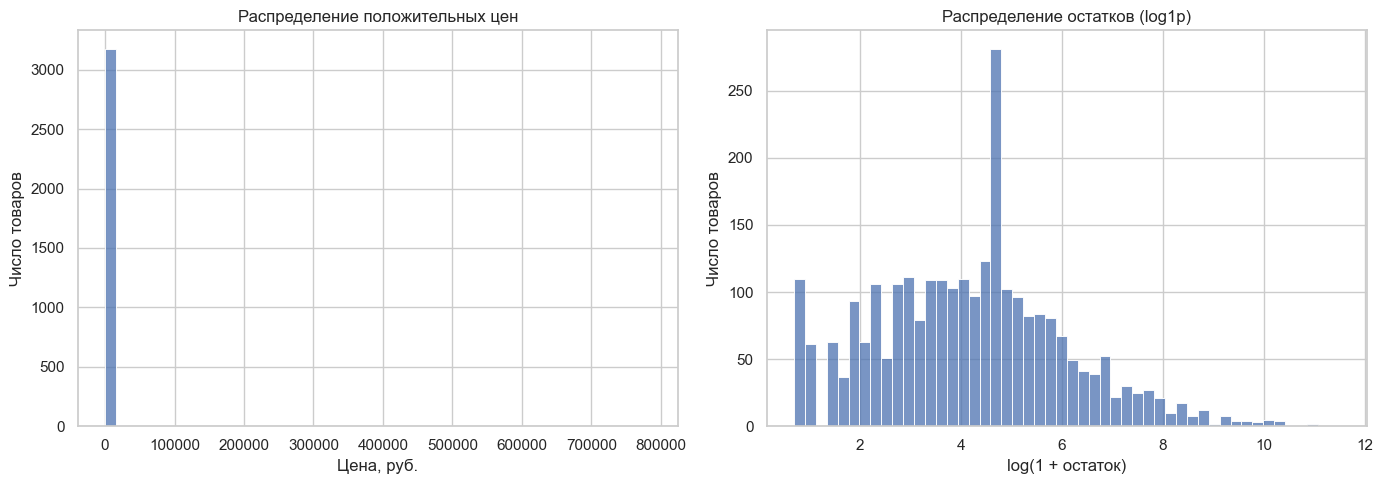

,товаров
categories,
Адаптеры BSP,448
Китай,432
Фитинги для РВД,373
DK,309
BSP,275
Фланцы SF,252
DKOL,224
JIC,217
ORFS,173


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

positive_prices = products_df.loc[products_df["price"].fillna(0) > 0, "price"]
sns.histplot(positive_prices, bins=50, ax=axes[0])
axes[0].set(title="Распределение положительных цен", xlabel="Цена, руб.", ylabel="Число товаров")

numeric_stock = products_df.loc[products_df["stock_quantity"].notna(), "stock_quantity"]
sns.histplot(np.log1p(numeric_stock), bins=50, ax=axes[1])
axes[1].set(title="Распределение остатков (log1p)", xlabel="log(1 + остаток)", ylabel="Число товаров")

plt.tight_layout()
plt.show()

top_categories = (
    products_df["categories"].fillna("[]").map(json.loads).explode().dropna().value_counts().head(20)
)
display(top_categories.rename("товаров").to_frame())


## 10. Постановка NLP-задачи

**Объект:** товарная позиция.  
**Текстовое описание:** название + полное описание + все характеристики.  
**Целевая переменная:** фактическая положительная цена в рублях (`price`).

Цена непрерывная, поэтому по условию задания применяется линейная регрессия. Ridge — линейная регрессия с L2-регуляризацией коэффициентов; её параметр `alpha` подбирается кросс-валидацией **только на train**. Это не противоречит требованию отключить L2-нормировку TF–IDF: у `TfidfVectorizer` отдельно установлено `norm=None`.

Из моделирования исключаются:

- `price <= 0`, поскольку это маркер «Под заказ», а не бесплатный товар;
- пустые/слишком короткие тексты;
- дубликаты одной canonical-карточки.

Ни цена, ни остаток не добавляются в текст признаков — утечки целевой переменной нет.


In [27]:
RU_STOP_WORDS = """
а без более больше будет будто бы был была были было быть в вам вас весь во вот все всего всех вы где да даже для
до его ее если есть еще же за здесь и из или им их к как какая какой когда ко кто ли либо мне может мы на над надо
наш не него нее нет ни них но ну о об один она они оно от по под при про раз с сам сама сами самого свое свою себя
со так такой там те тем то того тоже той только том ты у уже хотя чего чей чем что чтобы чье эта эти это этого этой
я ваш также очень который которая которые которых которого которой котором которой между после перед при этом
""".split()

model_df = products_df.copy()
model_df["price"] = pd.to_numeric(model_df["price"], errors="coerce")
model_df["text_for_model"] = model_df["text_for_model"].fillna("").map(clean_text)
model_df = model_df[
    model_df["price"].gt(0)
    & model_df["text_for_model"].str.len().ge(40)
].drop_duplicates("canonical_url").reset_index(drop=True)

print("Наблюдений для моделирования:", len(model_df))
print("Медианная цена:", round(model_df["price"].median(), 2), "руб.")
assert len(model_df) >= 30, "Для устойчивого train/test и CV нужно хотя бы 30 товаров с текстом и положительной ценой."


Наблюдений для моделирования: 3187
Медианная цена: 108.33 руб.


## 11. Train/test 75/25, TF–IDF и настройка Ridge

Векторизатор использует отдельные токены и биграммы (`ngram_range=(1, 2)`), русские стоп-слова, `min_df` и `max_df=0.95`. `norm=None` отключает включённую по умолчанию L2-нормировку документов.


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    model_df["text_for_model"],
    model_df["price"],
    test_size=0.25,
    random_state=RANDOM_STATE,
)

adaptive_min_df = max(2, int(len(X_train) * 0.001))
cv_splits = 5 if len(X_train) >= 100 else 3

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        stop_words=RU_STOP_WORDS,
        min_df=adaptive_min_df,
        max_df=0.95,
        norm=None,
        sublinear_tf=True,
        token_pattern=r"(?u)\b[а-яёa-z0-9][а-яёa-z0-9.+/-]{1,}\b",
        dtype=np.float64,
    )),
    ("regressor", Ridge(solver="lsqr")),
])

param_grid = {"regressor__alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
cv = KFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
grid.fit(X_train, y_train)

print("Train:", len(X_train), "| Test:", len(X_test), "| test share:", round(len(X_test) / len(model_df), 3))
print("min_df:", adaptive_min_df, "| признаков:", len(grid.best_estimator_.named_steps["tfidf"].get_feature_names_out()))
print("Лучший alpha:", grid.best_params_["regressor__alpha"])
print("CV MAE:", round(-grid.best_score_, 2), "руб.")


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Train: 2390 | Test: 797 | test share: 0.25
min_df: 2 | признаков: 7175
Лучший alpha: 1.0
CV MAE: 890.38 руб.


,param_regressor__alpha,cv_mae,cv_mae_std,rank_test_score
0,0.01,923.999416,664.119781,5
1,0.10,912.715369,654.367937,4
2,1.00,890.375667,652.426162,1
3,10.00,891.181916,657.734120,2
4,100.00,896.005614,722.294913,3
5,1000.00,1055.013714,1071.010380,6


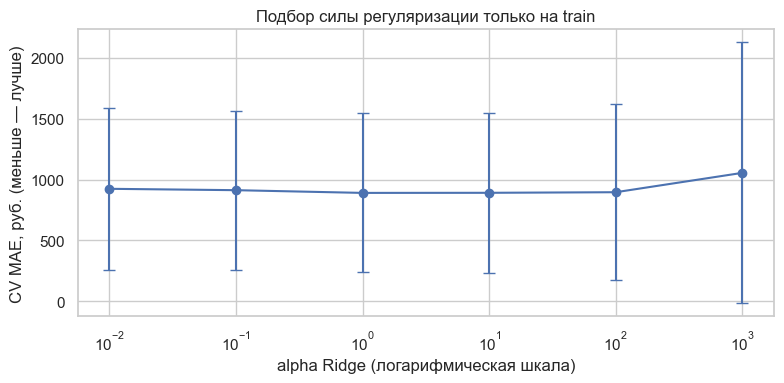

In [29]:
cv_results = pd.DataFrame(grid.cv_results_).sort_values("param_regressor__alpha")
cv_results["cv_mae"] = -cv_results["mean_test_score"]
cv_results["cv_mae_std"] = cv_results["std_test_score"]
display(cv_results[["param_regressor__alpha", "cv_mae", "cv_mae_std", "rank_test_score"]])

plt.figure(figsize=(8, 4))
plt.errorbar(
    cv_results["param_regressor__alpha"].astype(float),
    cv_results["cv_mae"],
    yerr=cv_results["cv_mae_std"],
    marker="o", capsize=4,
)
plt.xscale("log")
plt.xlabel("alpha Ridge (логарифмическая шкала)")
plt.ylabel("CV MAE, руб. (меньше — лучше)")
plt.title("Подбор силы регуляризации только на train")
plt.tight_layout()
plt.show()


## 12. Качество на отложенном test

Baseline всегда предсказывает медиану обучающей выборки. Модель полезна только если её ошибки ниже baseline. MAPE приводится как вспомогательная метрика: при дешёвых товарах она нестабильна, поэтому основные метрики — MAE, RMSE и R².


In [30]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

baseline = DummyRegressor(strategy="median")
baseline.fit(np.zeros((len(y_train), 1)), y_train)
y_base = baseline.predict(np.zeros((len(y_test), 1)))


def regression_metrics(y_true, y_hat):
    return {
        "MAE, руб.": mean_absolute_error(y_true, y_hat),
        "RMSE, руб.": mean_squared_error(y_true, y_hat) ** 0.5,
        "R²": r2_score(y_true, y_hat),
        "MAPE, %": mean_absolute_percentage_error(y_true, y_hat) * 100,
    }


metrics_df = pd.DataFrame({
    "Ridge TF-IDF": regression_metrics(y_test, y_pred),
    "Median baseline": regression_metrics(y_test, y_base),
}).T
display(metrics_df.round(3))

prediction_df = model_df.loc[X_test.index, ["name", "sku", "price", "canonical_url"]].copy()
prediction_df["prediction"] = y_pred
prediction_df["absolute_error"] = np.abs(prediction_df["price"] - prediction_df["prediction"])
display(prediction_df.sort_values("absolute_error", ascending=False).head(15))

joblib.dump(best_model, MODEL_PATH)
print("Модель сохранена:", MODEL_PATH.resolve())


,"MAE, руб.","RMSE, руб.",R²,"MAPE, %"
Ridge TF-IDF,418.603,1213.724,0.209,356.172
Median baseline,380.645,1403.542,-0.058,127.524


,name,sku,price,canonical_url,prediction,absolute_error
2810,РВД 38-9-7000/ DKOS 52х2 (0)(Г)/ DKOS 52х2 (0)(Г)/ 0,4180-rvd-sb-1,22712.55,https://store.rvdural.ru/rvd-v-sbore/rvd-38-9-7000-dkos-52h2-0-g-dkos-52h2-0-g-0/,10022.635730,12689.914270
3039,"2"" 1SN Рукав высокого давления Dy50 Py 40 Semperit",HPH-E-1SN-50 SMP,2350.47,https://store.rvdural.ru/rvd/rvd-1sn/2-1sn-rukav-vysokogo-davleniya-dy50-py-40-semperit/,12448.512063,10098.042063
3038,"2"" 1SN Рукав высокого давления Dy50 Py 40 Китай",HPH-C-1SN-50,654.30,https://store.rvdural.ru/rvd/rvd-1sn/2-1sn-rukav-vysokogo-davleniya-dy50-py-40-kitaj/,10373.424831,9719.124831
3029,"25 РВД 1SN 1"" Py88 Китай",HPH-C-1SN-25,327.65,https://store.rvdural.ru/rvd/rvd-1sn/1-1sn-rukav-vysokogo-davleniya-dy25-py88-kitaj/,-8793.431616,9121.081616
2783,РВД 20-35-1000/ DKOS 30х2 (90)(Г)/ DKOS 30х2 (90)(Г)/ 180,4153-rvd-sb-1,4286.16,https://store.rvdural.ru/rvd-v-sbore/rvd-20-35-1000-dkos-30h2-90-g-dkos-30h2-90-g-180/,13054.120726,8767.960726
2762,РВД 12-27.5-4600/ BSP 1/2 (Ш) L=35/ BSP 1/2 (45)(Г)/ 0,4197-rvd-sb-1,3025.29,https://store.rvdural.ru/rvd-v-sbore/rvd-12-27-5-4600-bsp-1-2-sh-l-35-bsp-1-2-45-g-0/,-4115.850537,7141.140537
14,"Адаптер BSP 1.1/4"" Ш - BSPT 1"" Ш-к S=50 — 1BT-20-16SP",1BT-20-16SP,314.26,https://store.rvdural.ru/adaptery/adaptery-bsp/adapter-0-bsp-bspt-1-1-4-1-sh-sh-k-s-50-art-1bt-20-16sp/,6043.361654,5729.101654
3057,"10 РВД 2SC 3/8"" (-50 C) SEMPERCOLD",HPH-E-2SC-10 SMP-C,376.99,https://store.rvdural.ru/rvd/rvd-2sc/10-rvd-2sc-3-8-50-c-sempercold/,6094.897615,5717.907615
3058,"12 РВД 2SC 1/2"" (-50C) SEMPERCOLD",HPH-E-2SC-12 SMP-C,402.35,https://store.rvdural.ru/rvd/rvd-2sc/12-rvd-2sc-1-2-50c-sempercold/,5724.305745,5321.955745
2440,"2"" РБ 50*35 МПа S.F.=2,5 L=36 м -55°",HPH-C-R13-50-C DH,2300.64,https://store.rvdural.ru/prochee/burovye-komplektuyushchie/2-rukav-burovoj-50-35-mpa-s-f-2-5-l-36-m-55/,-2733.717915,5034.357915


Модель сохранена: C:\Users\Admin\OTUS.Professional\Homework_07\data_rvdural\ridge_tfidf_price.joblib


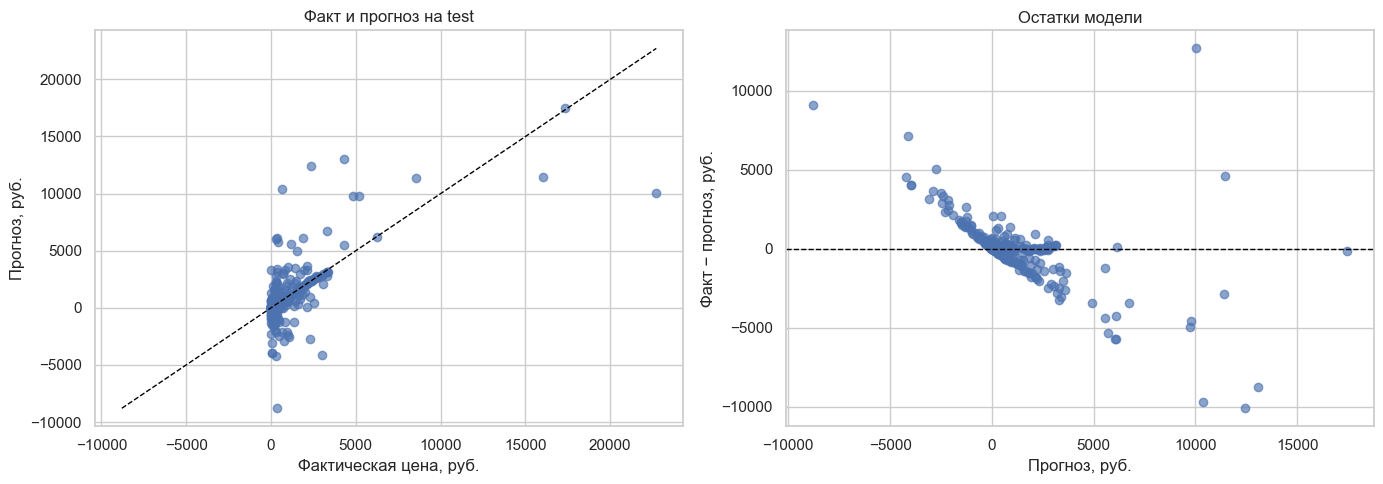

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.65)
low = min(float(y_test.min()), float(y_pred.min()))
high = max(float(y_test.max()), float(y_pred.max()))
axes[0].plot([low, high], [low, high], "--", color="black", linewidth=1)
axes[0].set(title="Факт и прогноз на test", xlabel="Фактическая цена, руб.", ylabel="Прогноз, руб.")

residuals = y_test.to_numpy() - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.65)
axes[1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1].set(title="Остатки модели", xlabel="Прогноз, руб.", ylabel="Факт − прогноз, руб.")

plt.tight_layout()
plt.show()


## 13. Топ-50 коэффициентов регрессии

Показываются 50 признаков с максимальным абсолютным коэффициентом. Красные признаки сдвигают прогноз вниз, зелёные — вверх. Это статистические связи в текущем ассортименте, а не причинный эффект и не «наценка за слово». Из-за `norm=None` единица коэффициента — одна единица ненормированного TF–IDF данного токена/биграммы.


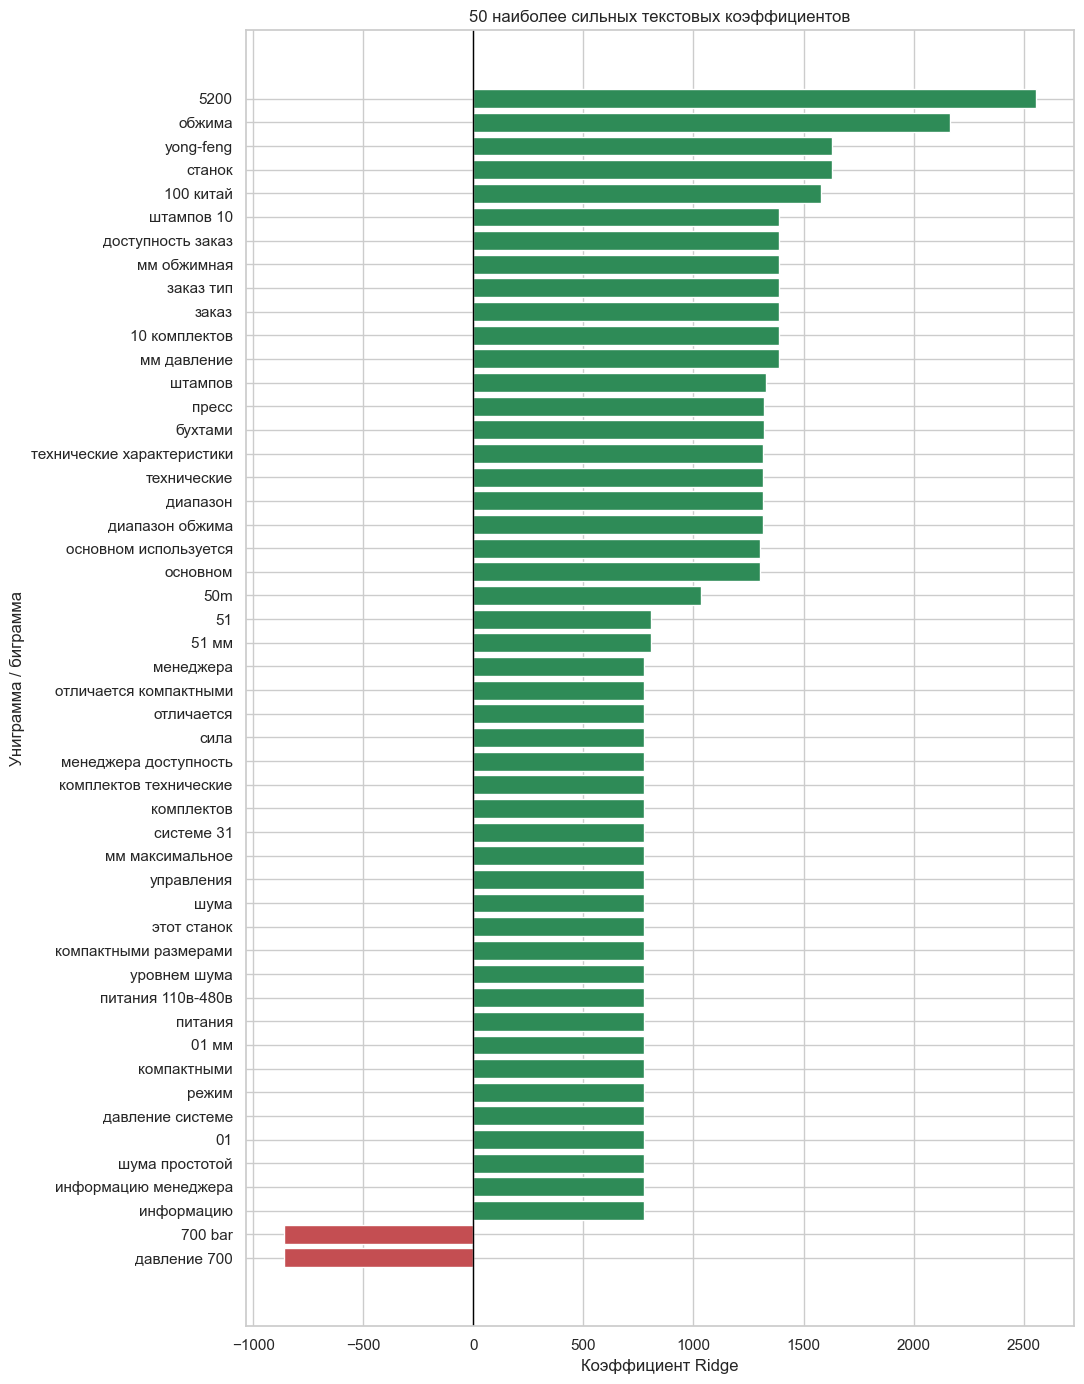

,снижает прогноз,коэффициент
27,давление 700,-861.373065
26,700 bar,-861.373065
0,информацию,776.248747
1,информацию менеджера,776.248747
4,шума простотой,776.248747
5,01,776.248747
2,давление системе,776.248747
3,режим,776.248747
8,компактными,776.248747
9,01 мм,776.248747


,повышает прогноз,коэффициент
49,5200,2557.496285
48,обжима,2163.622182
46,станок,1629.045159
47,yong-feng,1629.045159
45,100 китай,1578.381245
40,заказ,1390.201744
41,заказ тип,1390.201744
44,штампов 10,1390.201744
42,мм обжимная,1390.201744
43,доступность заказ,1390.201744


In [32]:
vectorizer = best_model.named_steps["tfidf"]
regressor = best_model.named_steps["regressor"]
feature_names = vectorizer.get_feature_names_out()
coefficients = regressor.coef_.ravel()

top_indices = np.argsort(np.abs(coefficients))[-50:]
coef_df = pd.DataFrame({
    "token": feature_names[top_indices],
    "coefficient": coefficients[top_indices],
}).sort_values("coefficient")

plt.figure(figsize=(11, 14))
colors = np.where(coef_df["coefficient"] >= 0, "#2e8b57", "#c44e52")
plt.barh(coef_df["token"], coef_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Коэффициент Ridge")
plt.ylabel("Униграмма / биграмма")
plt.title("50 наиболее сильных текстовых коэффициентов")
plt.tight_layout()
plt.show()

display(coef_df.head(10).rename(columns={"token": "снижает прогноз", "coefficient": "коэффициент"}))
display(coef_df.tail(10).sort_values("coefficient", ascending=False).rename(columns={"token": "повышает прогноз", "coefficient": "коэффициент"}))


## 14. Итоги

**Почему выбран этот датасет?** Карточка товара содержит развернутое текстовое описание и измеримую непрерывную цель — цену. Дополнительно есть остаток, производитель, категории, характеристики и изображения. Это соответствует требуемой постановке «текст объекта + целевая переменная».

**Какая переменная предсказывается?** Цена в рублях. Статусные нулевые цены «Под заказ» не используются как цель. Остаток не смешивается с ценой и остаётся самостоятельным полем исходного датасета.

**Как подготовлен текст?** Объединены название, описание и характеристики; применён TF–IDF с униграммами и биграммами, русскими стоп-словами, `min_df`, `max_df=0.95` и `norm=None`. HTML, цена и остаток в признаки не попадают.

**Как исключена утечка?** Разбиение 75/25 выполняется до обучения TF–IDF. Словарь, IDF и `alpha` подбираются внутри `Pipeline` и CV только на train; test используется один раз для финальной оценки.

**Как настроена модель?** Для Ridge перебираются значения `alpha` от 0.01 до 1000 по MAE на перемешанной KFold-кросс-валидации. Это контролирует переобучение большого разреженного пространства слов и биграмм.

**Как трактовать качество?** MAE — типичная абсолютная ошибка в рублях; RMSE сильнее штрафует редкие крупные промахи; R² сравнивает модель с предсказанием среднего; MAPE показывает относительную ошибку, но переоценивает ошибки дешёвых позиций. Обязательная практическая проверка — сравнение с медианным baseline.

**Как трактовать коэффициенты?** Положительный коэффициент связан с более высокой ценой при прочих признаках, отрицательный — с более низкой. Коррелированные слова и характеристики делят вес между собой, поэтому отдельный коэффициент не является причинной наценкой.

**Ограничения:** цена зависит не только от текста, но и от бренда, закупочных условий, скидок и товарной группы; распределение цен обычно имеет длинный правый хвост; несколько почти одинаковых SKU могут попадать в разные части случайного split. Для промышленной оценки полезно добавить GroupKFold по семейству/артикулу и сравнить с логарифмом цены, символьными n-граммами и моделями, использующими категорию и производителя.


In [33]:
ridge_mae = metrics_df.loc["Ridge TF-IDF", "MAE, руб."]
base_mae = metrics_df.loc["Median baseline", "MAE, руб."]
r2 = metrics_df.loc["Ridge TF-IDF", "R²"]
gain = (base_mae - ridge_mae) / base_mae * 100

print(f"Лучший alpha: {grid.best_params_['regressor__alpha']}")
print(f"Test MAE: {ridge_mae:,.2f} руб.; baseline MAE: {base_mae:,.2f} руб.")
print(f"Изменение MAE относительно baseline: {gain:+.1f}% (положительное значение означает улучшение).")
print(f"Test R²: {r2:.3f}.")

if ridge_mae < base_mae and r2 > 0:
    print("Вывод: текст несёт полезный ценовой сигнал и модель превосходит простой baseline.")
elif ridge_mae < base_mae:
    print("Вывод: MAE лучше baseline, но R² не положителен; качество нестабильно на дорогих товарах.")
else:
    print("Вывод: текстовой модели недостаточно; цена сильнее определяется нетекстовыми факторами.")

print("\nСильнейшие признаки повышения прогноза:")
print(", ".join(coef_df.nlargest(10, "coefficient")["token"]))
print("Сильнейшие признаки снижения прогноза:")
print(", ".join(coef_df.nsmallest(10, "coefficient")["token"]))


Лучший alpha: 1.0
Test MAE: 418.60 руб.; baseline MAE: 380.64 руб.
Изменение MAE относительно baseline: -10.0% (положительное значение означает улучшение).
Test R²: 0.209.
Вывод: текстовой модели недостаточно; цена сильнее определяется нетекстовыми факторами.

Сильнейшие признаки повышения прогноза:
5200, обжима, станок, yong-feng, 100 китай, мм давление, 10 комплектов, заказ, заказ тип, мм обжимная
Сильнейшие признаки снижения прогноза:
давление 700, 700 bar, информацию, информацию менеджера, шума простотой, 01, давление системе, режим, компактными, 01 мм
